In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
RANDOM_SEED = 42
LEARNING_RATE = 1e-3
BATCH_SIZE = 64

In [3]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device =torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
DATA_DIR = '../data/processed/'

X_train = np.load(DATA_DIR + 'X_train.npy')
X_val   = np.load(DATA_DIR + 'X_val.npy')
X_test  = np.load(DATA_DIR + 'X_test.npy')
y_train = np.load(DATA_DIR + 'y_train.npy')
y_val   = np.load(DATA_DIR + 'y_val.npy')
y_test  = np.load(DATA_DIR + 'y_test.npy')

X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_val_t = torch.tensor(X_val, dtype = torch.float32)
X_test_t = torch.tensor(X_test, dtype = torch.float32)

y_train_t = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

In [5]:
class Housingdata(Dataset):
    def __init__(self, X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
training_dataset = Housingdata(X_train_t, y_train_t)
val_dataset = Housingdata(X_val_t, y_val_t)
test_dataset = Housingdata(X_test_t, y_test_t)

In [7]:
train_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle= False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=False, num_workers=0)

In [8]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, D_in, hidden_layers, D_out, dropout = 0.2 ):
        super(MultiLayerPerceptron, self).__init__()
        layers = []
        previous_dim = D_in

        for hidden_layer in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_layer

        layers.append(nn.Linear(previous_dim, D_out))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
        

In [9]:
n_features = X_train_t.shape[1]
hidden_dim = [64,32]

In [10]:
model = MultiLayerPerceptron(D_in = n_features, hidden_layers= hidden_dim, D_out= 1)
model = model.to(device)
print(model)

MultiLayerPerceptron(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [11]:
n_features

8

In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr = LEARNING_RATE)
N_epochs = 100

In [13]:
train_losses = []
val_losses = []

for epoch in range(N_epochs):
    model.train()
    epoch_train_loss = 0
    
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch) 
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss/len(train_loader)
    train_losses.append(avg_train_loss)    

    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            val_prediction = model(X_batch)
            val_loss = criterion(val_prediction, y_batch)

            epoch_val_loss += val_loss.item()

        avg_val_loss = epoch_val_loss/len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"for epoch {epoch}, training_loss: {avg_train_loss:.4f} and validation_loss: {avg_val_loss:.4f}")

for epoch 0, training_loss: 1.9472 and validation_loss: 0.7037
for epoch 1, training_loss: 0.7623 and validation_loss: 0.5204
for epoch 2, training_loss: 0.6194 and validation_loss: 0.4642
for epoch 3, training_loss: 0.5835 and validation_loss: 0.4426
for epoch 4, training_loss: 0.5533 and validation_loss: 0.4270
for epoch 5, training_loss: 0.5415 and validation_loss: 0.4233
for epoch 6, training_loss: 0.5254 and validation_loss: 0.4084
for epoch 7, training_loss: 0.5140 and validation_loss: 0.4100
for epoch 8, training_loss: 0.5009 and validation_loss: 0.3997
for epoch 9, training_loss: 0.4880 and validation_loss: 0.3885
for epoch 10, training_loss: 0.4664 and validation_loss: 0.3862
for epoch 11, training_loss: 0.4743 and validation_loss: 0.3838
for epoch 12, training_loss: 0.4607 and validation_loss: 0.3771
for epoch 13, training_loss: 0.4523 and validation_loss: 0.3836
for epoch 14, training_loss: 0.4416 and validation_loss: 0.3806
for epoch 15, training_loss: 0.4331 and validation

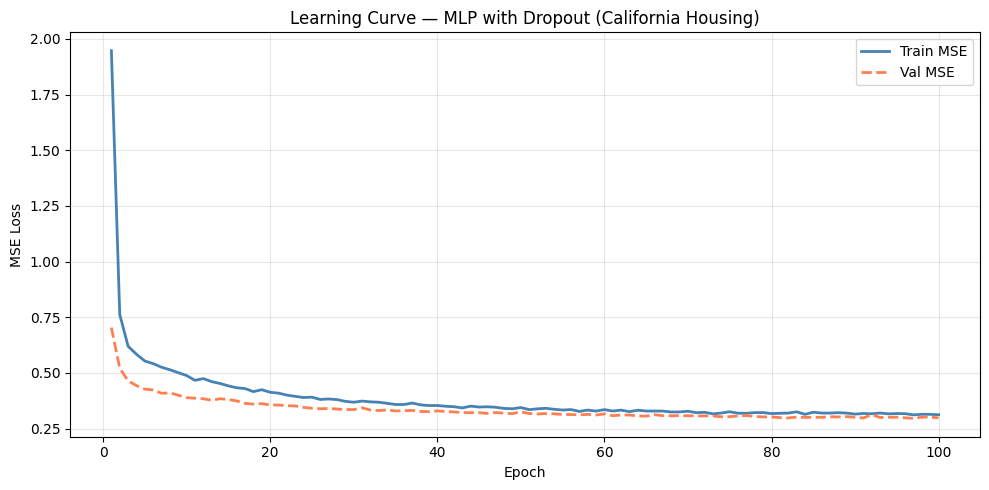

Final Train MSE: 0.3119
Final Val   MSE: 0.2973


In [14]:
plt.figure(figsize=(10, 5))

epochs_range = range(1, N_epochs + 1)

plt.plot(epochs_range, train_losses, label='Train MSE', color='steelblue',  linewidth=2)
plt.plot(epochs_range, val_losses,   label='Val MSE',   color='coral',      linewidth=2, linestyle='--')


plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curve — MLP with Dropout (California Housing)')
plt.legend()
plt.grid(True, alpha=0.3)  
plt.tight_layout()

os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/MLP_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final Train MSE: {train_losses[-1]:.4f}')
print(f'Final Val   MSE: {val_losses[-1]:.4f}')

In [15]:
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)

        all_preds.append(preds.cpu().numpy().flatten())
        all_true.append(y_batch.cpu().numpy().flatten())

y_pred_val = np.concatenate(all_preds)
y_true_val = np.concatenate(all_true)

mse  = np.mean((y_pred_val - y_true_val) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_pred_val - y_true_val))

print(f'  MSE:  {mse:.4f} ')
print(f'  RMSE: {rmse:.4f}  ')
print(f'  MAE:  {mae:.4f} ')

  MSE:  0.2802 
  RMSE: 0.5293  
  MAE:  0.3597 


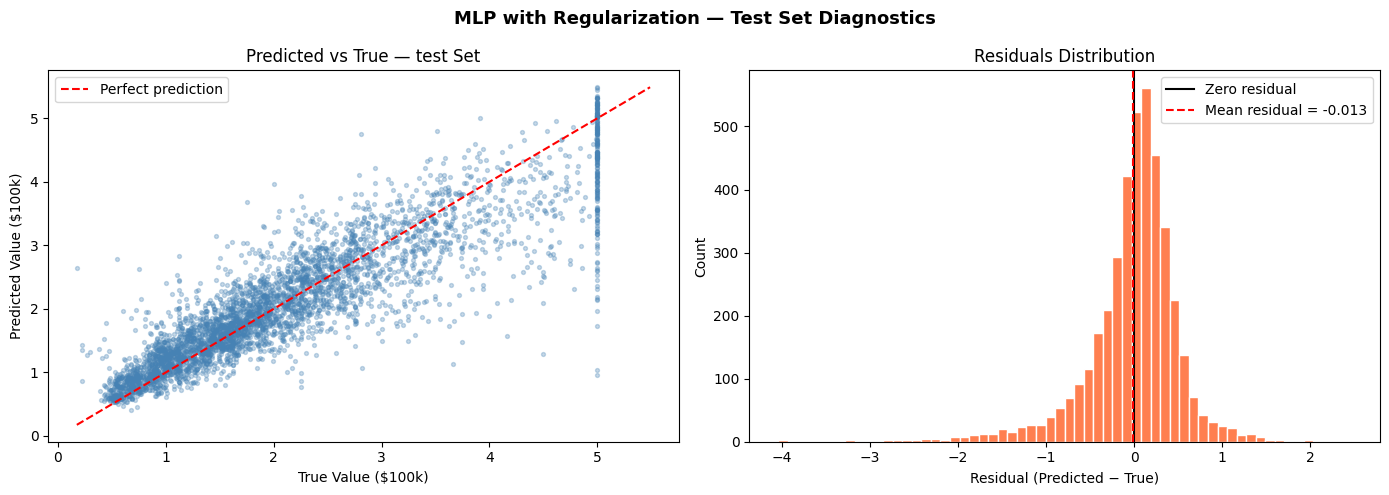

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true_val, y_pred_val, alpha=0.3, s=8, color='steelblue')

lims = [min(y_true_val.min(), y_pred_val.min()),
        max(y_true_val.max(), y_pred_val.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
# 'r--' → red dashed line
axes[0].set_xlabel('True Value ($100k)')
axes[0].set_ylabel('Predicted Value ($100k)')
axes[0].set_title('Predicted vs True — test Set')
axes[0].legend()

residuals = y_pred_val - y_true_val
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, label='Zero residual')
axes[1].axvline(residuals.mean(), color='red', linestyle='--',
                label=f'Mean residual = {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Predicted − True)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution')
axes[1].legend()

plt.suptitle('MLP with Regularization — Test Set Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/MLP_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()